# NBA Draft Prospect Predictor
**CS 451 Final Project** — Predicting Early NBA Career Value from College Performance

This notebook implements the full data science pipeline:
1. Problem Definition & Data Acquisition
2. Data Cleaning & Feature Engineering
3. Modeling & Evaluation
4. Export for Deployment

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

FIGURES_DIR = '../figures/'
MODELS_DIR = '../models/'
SITE_DATA_DIR = '../site/data/'

## Stage 1: Problem Definition & Data Acquisition

**Problem:** NBA teams spend millions scouting draft prospects. Can we predict a player's early career NBA impact (4-year VORP) from their college statistics and high school recruiting profile?

**Data Sources:**
- **Basketball Reference** (basketball-reference.com) — NBA draft history, college career statistics, advanced metrics, and 4-year NBA outcomes for all drafted college players 2000–2022
- **247Sports** (247sports.com) — High school recruiting rankings and composite grades

**Target Variable:** `nba_4yr_vorp` — cumulative Value Over Replacement Player across a player's first 4 NBA seasons, measuring total on-court impact during the rookie contract window.

**Dataset:** 1,043 college players drafted into the NBA between 2000 and 2022.

In [97]:
# Load dataset
df = pd.read_csv('../fixeddata.csv')
print(f"Dataset shape: {df.shape}")
print(f"Draft years: {df['draft_year'].min():.0f} – {df['draft_year'].max():.0f}")
print(f"Positions: {df['position'].value_counts().to_dict()}")
print(f"\nTarget completeness:")
for col in ['nba_4yr_bpm', 'nba_4yr_vorp', 'nba_4yr_ws', 'PosVORP', 'bpm_tier']:
    print(f"  {col}: {df[col].notna().sum()}/{len(df)} non-null")
df.head()

Dataset shape: (1042, 43)
Draft years: 2000 – 2022
Positions: {'Guard': 480, 'Forward': 442, 'Center': 120}

Target completeness:
  nba_4yr_bpm: 1042/1042 non-null
  nba_4yr_vorp: 1042/1042 non-null
  nba_4yr_ws: 1042/1042 non-null
  PosVORP: 1042/1042 non-null
  bpm_tier: 1042/1042 non-null


,player_name,draft_year,pick_number,college,height_inches,weight_lbs,position,ppg,apg,rpg,...,nba_seasons,nba_4yr_total_mp,nba_4yr_bpm,nba_4yr_vorp,nba_4yr_ws,career_ws48,meaningful_career,bpm_tier,minutes_tier,PosVORP
0,Kenyon Martin,2000,1,Cincinnati,81,234,Center,11.025862,1.224138,7.491379,...,15,9656,0.419014,5.9,20.8,0.100,1,Starter+,Starter+,1
1,Stromile Swift,2000,2,LSU,81,225,Forward,13.420000,0.740000,6.960000,...,9,6123,-0.622701,2.1,13.7,0.095,1,Rotation,Starter+,1
2,Marcus Fizer,2000,4,Iowa State,81,262,Forward,18.865979,0.969072,7.381443,...,6,5089,-3.862645,-2.4,2.3,0.022,1,Bust,Starter+,0
3,Mike Miller,2000,5,Florida,80,218,Forward,13.261538,2.292308,5.984615,...,17,8525,-0.139742,3.9,16.7,0.105,1,Rotation,Starter+,1
4,DerMarr Johnson,2000,6,Cincinnati,81,201,Guard,12.562500,1.406250,3.843750,...,7,3327,-2.211362,-0.2,2.1,0.052,1,Rotation,Rotation,0


In [98]:
# Summary statistics for key columns
stat_cols = ['ppg', 'apg', 'rpg', 'spg', 'bpg', 'mpg', 'ts_pct', 'ws_40', 
             'recruit_rank', 'college_seasons', 'nba_4yr_vorp', 'nba_4yr_bpm']
df[stat_cols].describe().round(3)

,ppg,apg,rpg,spg,bpg,mpg,ts_pct,ws_40,recruit_rank,college_seasons,nba_4yr_vorp,nba_4yr_bpm
count,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000,1042.000
mean,12.956,2.172,5.515,1.047,0.846,28.171,0.567,0.178,63.826,2.693,1.149,-2.006
std,3.751,1.503,2.070,0.483,0.778,4.881,0.041,0.049,40.318,1.150,3.081,3.155
min,1.353,0.000,0.800,0.100,0.000,7.500,0.394,-0.006,1.000,1.000,-4.100,-25.900
25%,10.300,1.100,3.900,0.700,0.300,25.400,0.539,0.146,19.000,2.000,-0.400,-3.368
50%,13.051,1.800,5.200,1.000,0.600,28.977,0.565,0.176,88.000,3.000,0.000,-1.622
75%,15.343,2.800,6.884,1.300,1.137,31.702,0.591,0.204,101.000,4.000,1.800,0.000
max,27.516,8.700,12.700,2.900,5.400,38.282,0.739,0.413,101.000,5.000,28.500,8.120


### Exploratory Data Analysis

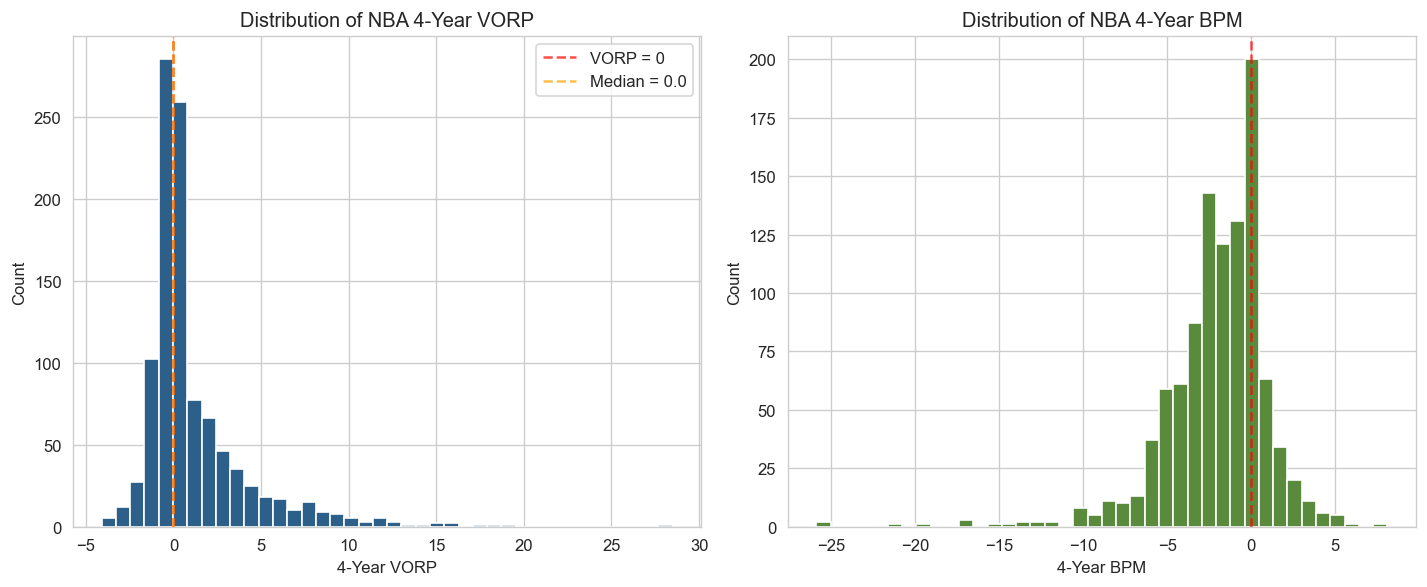

VORP — Mean: 1.15, Median: 0.00, Std: 3.08
BPM  — Mean: -2.01, Median: -1.62, Std: 3.16


In [99]:
# --- EDA Figure 1: Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['nba_4yr_vorp'].dropna().hist(bins=40, ax=axes[0], color='#2c5f8a', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='VORP = 0')
axes[0].axvline(df['nba_4yr_vorp'].dropna().median(), color='orange', linestyle='--', alpha=0.7, label=f"Median = {df['nba_4yr_vorp'].dropna().median():.1f}")
axes[0].set_xlabel('4-Year VORP')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of NBA 4-Year VORP')
axes[0].legend()

df['nba_4yr_bpm'].dropna().hist(bins=40, ax=axes[1], color='#5a8a3c', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('4-Year BPM')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of NBA 4-Year BPM')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '01_target_distribution.png', bbox_inches='tight')
plt.show()
print(f"VORP — Mean: {df['nba_4yr_vorp'].mean():.2f}, Median: {df['nba_4yr_vorp'].median():.2f}, Std: {df['nba_4yr_vorp'].std():.2f}")
print(f"BPM  — Mean: {df['nba_4yr_bpm'].mean():.2f}, Median: {df['nba_4yr_bpm'].median():.2f}, Std: {df['nba_4yr_bpm'].std():.2f}")

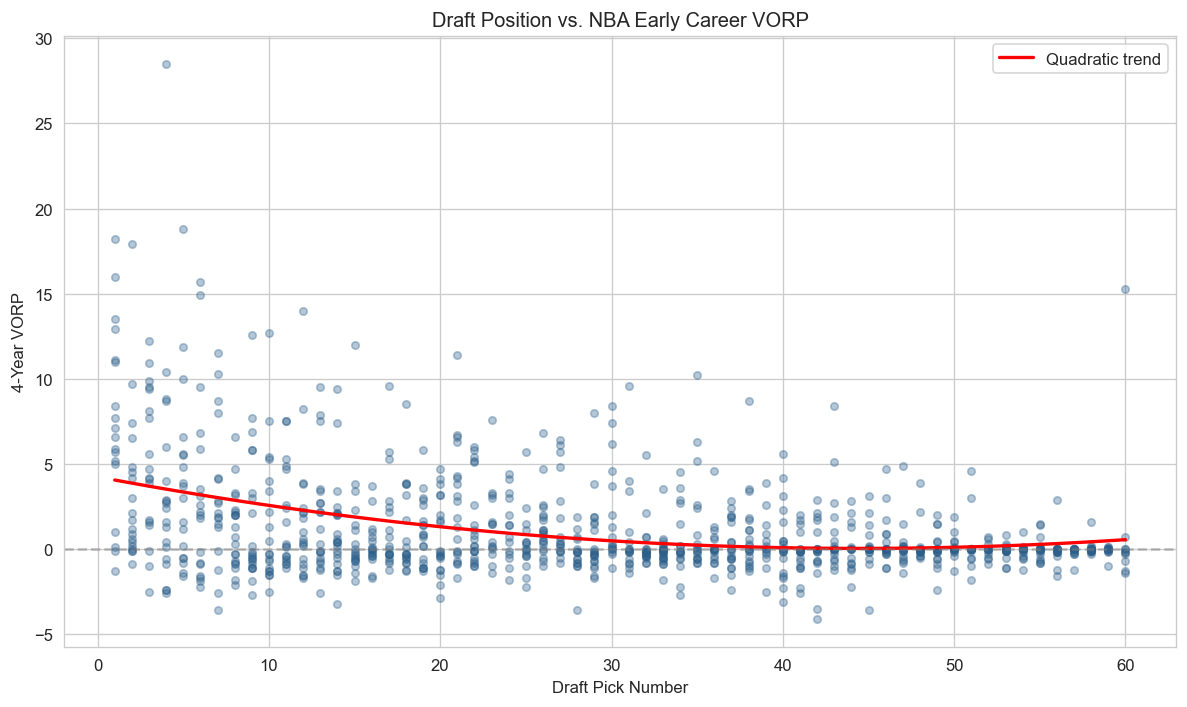

Correlation (pick_number vs VORP): r = -0.344


In [100]:
# --- EDA Figure 2: Draft Pick vs VORP ---
fig, ax = plt.subplots(figsize=(10, 6))
mask = df['nba_4yr_vorp'].notna()
ax.scatter(df.loc[mask, 'pick_number'], df.loc[mask, 'nba_4yr_vorp'], alpha=0.35, s=20, c='#2c5f8a')
# Add trend line
z = np.polyfit(df.loc[mask, 'pick_number'], df.loc[mask, 'nba_4yr_vorp'], 2)
x_line = np.linspace(1, 60, 100)
ax.plot(x_line, np.polyval(z, x_line), color='red', linewidth=2, label='Quadratic trend')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Draft Pick Number')
ax.set_ylabel('4-Year VORP')
ax.set_title('Draft Position vs. NBA Early Career VORP')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR + '02_pick_vs_vorp.png', bbox_inches='tight')
plt.show()
corr = df.loc[mask, ['pick_number', 'nba_4yr_vorp']].corr().iloc[0, 1]
print(f"Correlation (pick_number vs VORP): r = {corr:.3f}")

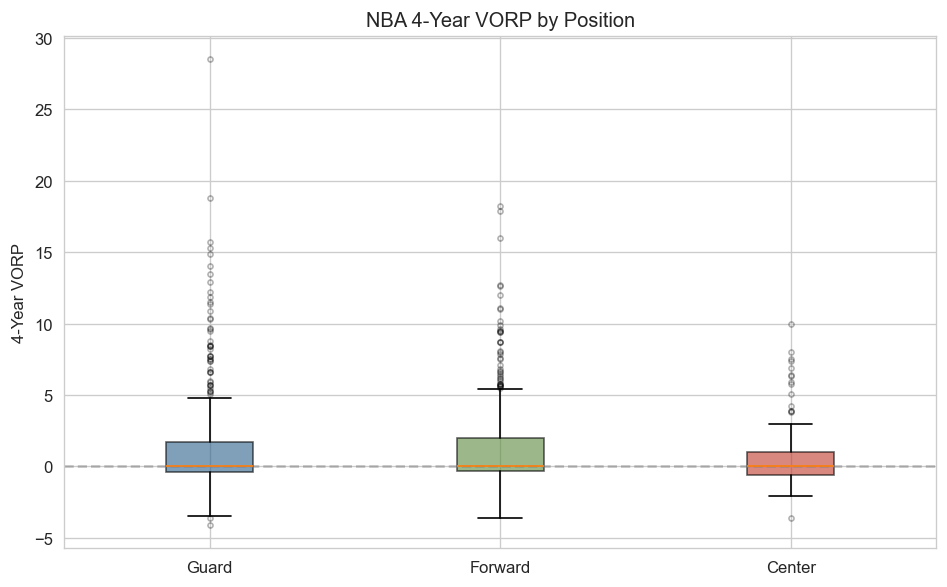

  Guard: n=480, mean=1.15, median=0.00
  Forward: n=442, mean=1.28, median=0.00
  Center: n=120, mean=0.65, median=0.00


In [101]:
# --- EDA Figure 3: VORP by Position ---
fig, ax = plt.subplots(figsize=(8, 5))
pos_order = ['Guard', 'Forward', 'Center']
colors = ['#2c5f8a', '#5a8a3c', '#c0392b']
data_by_pos = [df.loc[df['position'] == p, 'nba_4yr_vorp'].dropna() for p in pos_order]
bp = ax.boxplot(data_by_pos, labels=pos_order, patch_artist=True, showfliers=True,
                flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('4-Year VORP')
ax.set_title('NBA 4-Year VORP by Position')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '03_position_analysis.png', bbox_inches='tight')
plt.show()
for p in pos_order:
    v = df.loc[df['position'] == p, 'nba_4yr_vorp'].dropna()
    print(f"  {p}: n={len(v)}, mean={v.mean():.2f}, median={v.median():.2f}")

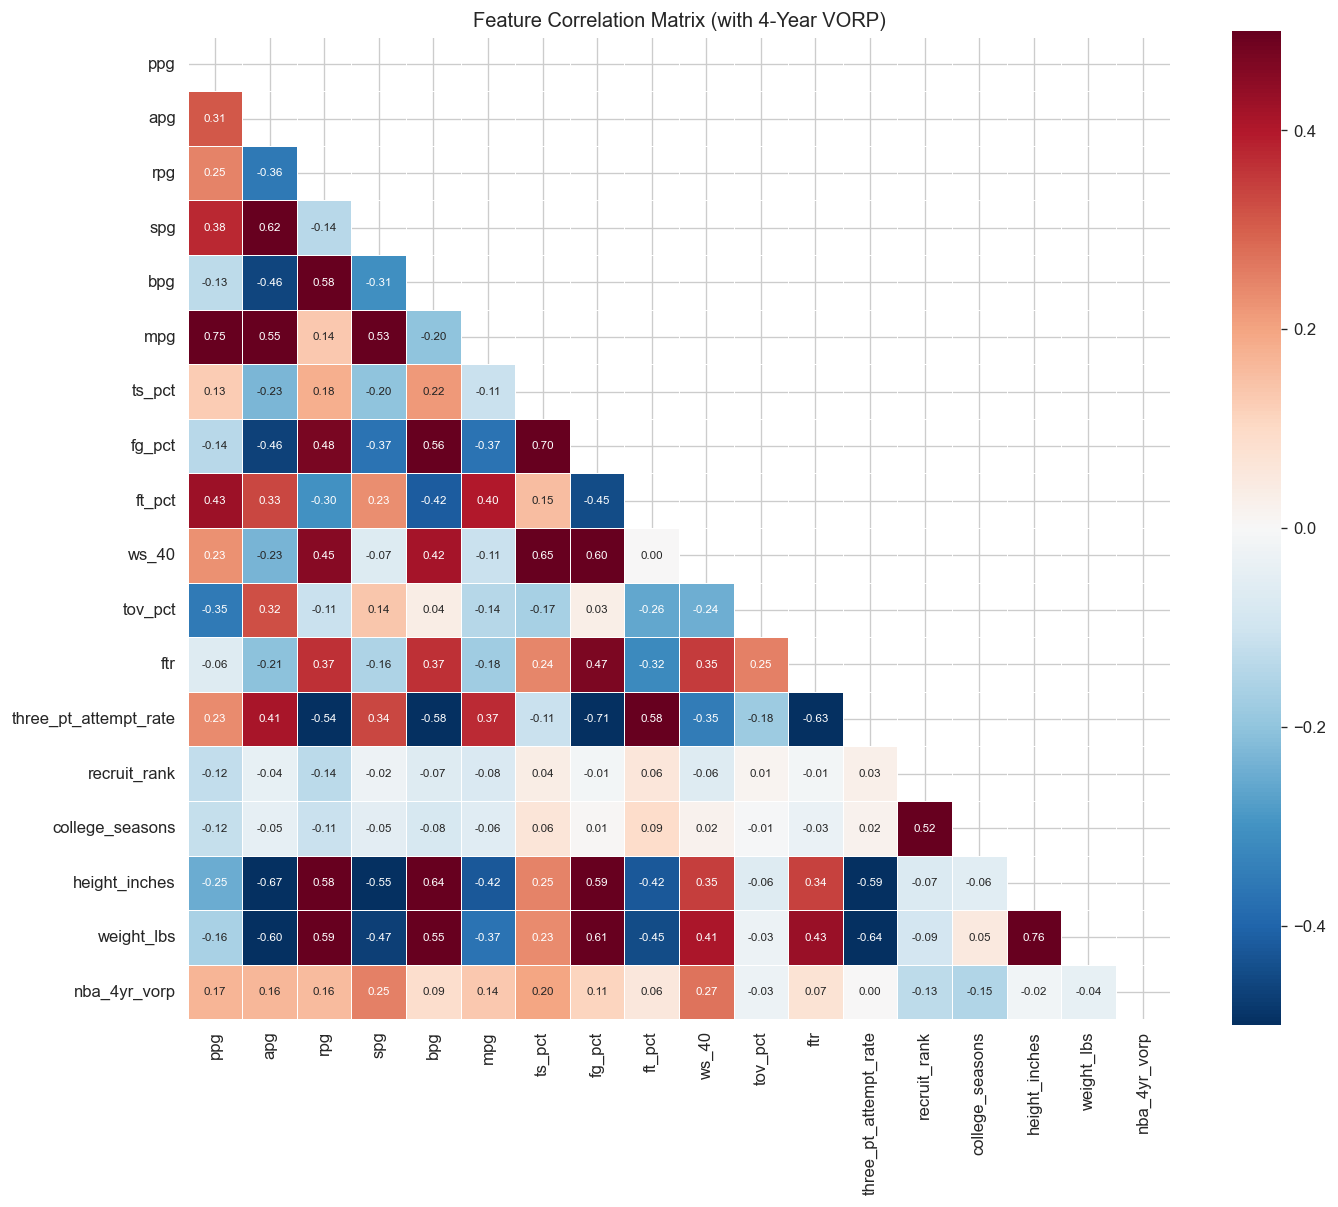

Top correlations with nba_4yr_vorp:
  ws_40: r = 0.272
  spg: r = 0.252
  ts_pct: r = 0.196
  ppg: r = 0.168
  apg: r = 0.165
  rpg: r = 0.160
  college_seasons: r = -0.151
  mpg: r = 0.136
  recruit_rank: r = -0.131
  fg_pct: r = 0.112


In [102]:
# --- EDA Figure 4: Correlation Heatmap (college stats vs NBA VORP) ---
corr_cols = ['ppg', 'apg', 'rpg', 'spg', 'bpg', 'mpg', 'ts_pct', 'fg_pct', 'ft_pct',
             'ws_40', 'tov_pct', 'ftr', 'three_pt_attempt_rate', 'recruit_rank',
             'college_seasons', 'height_inches', 'weight_lbs', 'nba_4yr_vorp']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5,
            annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (with 4-Year VORP)')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '04_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print top correlations with VORP
vorp_corr = corr_matrix['nba_4yr_vorp'].drop('nba_4yr_vorp').sort_values(key=abs, ascending=False)
print("Top correlations with nba_4yr_vorp:")
for feat, val in vorp_corr.head(10).items():
    print(f"  {feat}: r = {val:.3f}")

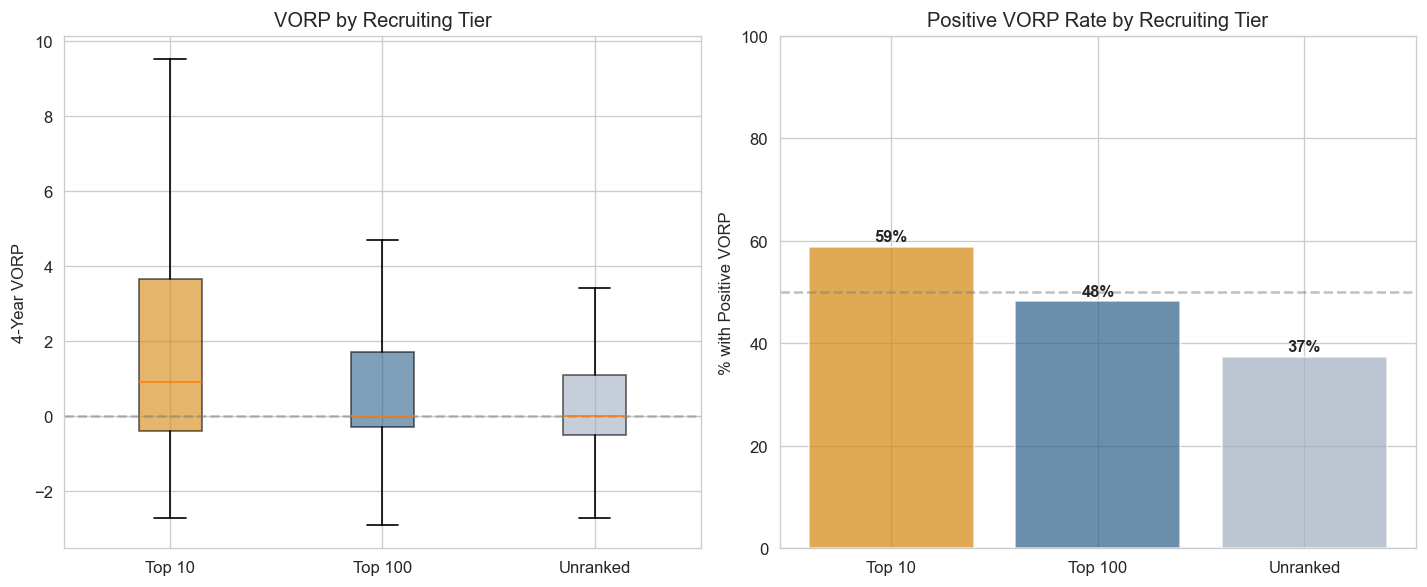

In [103]:
# --- EDA Figure 5: Recruiting Impact on NBA Outcomes ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Create recruit tiers
df_tmp = df.dropna(subset=['nba_4yr_vorp']).copy()
df_tmp['recruit_tier'] = pd.cut(df_tmp['recruit_rank'], 
                                 bins=[-1, 10, 100, 102], 
                                 labels=['Top 10', 'Top 100', 'Unranked'])

# Box plot
tier_order = ['Top 10', 'Top 100', 'Unranked']
data_by_tier = [df_tmp.loc[df_tmp['recruit_tier'] == t, 'nba_4yr_vorp'] for t in tier_order]
bp = axes[0].boxplot(data_by_tier, labels=tier_order, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], ['#d4850a', '#2c5f8a', '#a0aec0']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('4-Year VORP')
axes[0].set_title('VORP by Recruiting Tier')

# Hit rate (% positive VORP)
hit_rates = df_tmp.groupby('recruit_tier')['PosVORP'].mean() * 100
hit_rates = hit_rates.reindex(tier_order)
axes[1].bar(tier_order, hit_rates, color=['#d4850a', '#2c5f8a', '#a0aec0'], alpha=0.7, edgecolor='white')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.5)
for i, v in enumerate(hit_rates):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')
axes[1].set_ylabel('% with Positive VORP')
axes[1].set_title('Positive VORP Rate by Recruiting Tier')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES_DIR + '05_recruiting_impact.png', bbox_inches='tight')
plt.show()

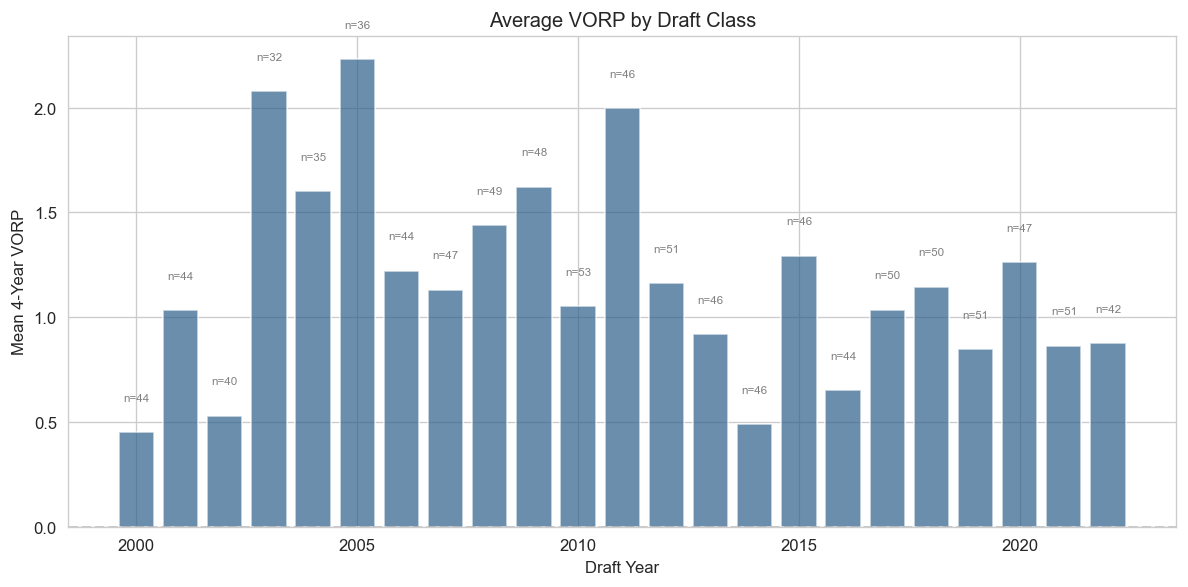

In [104]:
# --- EDA Figure 6: Draft Era Trends ---
fig, ax = plt.subplots(figsize=(10, 5))
yearly = df.groupby('draft_year').agg(
    mean_vorp=('nba_4yr_vorp', 'mean'),
    count=('nba_4yr_vorp', 'count')
).dropna()
ax.bar(yearly.index, yearly['mean_vorp'], color='#2c5f8a', alpha=0.7, edgecolor='white')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Draft Year')
ax.set_ylabel('Mean 4-Year VORP')
ax.set_title('Average VORP by Draft Class')
# Add player count annotations
for yr, row in yearly.iterrows():
    ax.text(yr, row['mean_vorp'] + 0.15, f"n={row['count']:.0f}", ha='center', fontsize=7, color='gray')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '06_draft_trends.png', bbox_inches='tight')
plt.show()

## Stage 2: Data Cleaning & Feature Engineering

### Data Cleaning
- Fix anomalous `fg_pct` values (2 players with impossible values)
- Drop rows with missing target variable (`nba_4yr_vorp`)
- Validate all feature ranges
- Document before/after quality comparisons

In [105]:
# --- Cleaning Step 1: Fix anomalous fg_pct values ---
print("Anomalous fg_pct values (> 1.0):")
anomalous = df[df['fg_pct'] > 1.0][['player_name', 'fg_pct', 'ts_pct', 'efg_pct']]
print(anomalous.to_string())

# Hamady N'Diaye: fg_pct=2.2, but ts_pct=0.559 and efg_pct=0.539 → likely 0.539
# Tristan Thompson: fg_pct=30.7, but ts_pct=0.536 and efg_pct=0.546 → likely 0.546 (decimal error)
df.loc[df['player_name'].str.contains("N'Diaye", na=False), 'fg_pct'] = 0.539
df.loc[df['player_name'].str.contains('Tristan Thompson', na=False), 'fg_pct'] = 0.546
print(f"\nFixed. Max fg_pct is now: {df['fg_pct'].max():.3f}")

Anomalous fg_pct values (> 1.0):
Empty DataFrame
Columns: [player_name, fg_pct, ts_pct, efg_pct]
Index: []

Fixed. Max fg_pct is now: 0.746


In [106]:
# --- Cleaning Step 2: Drop rows with missing target ---
n_before = len(df)
df_clean = df.dropna(subset=['nba_4yr_vorp']).copy()
n_after = len(df_clean)
print(f"Dropped {n_before - n_after} rows with missing nba_4yr_vorp")
print(f"Dataset: {n_before} → {n_after} rows")

# --- Cleaning Step 3: Validate feature ranges ---
print("\nFeature range validation:")
for col, lo, hi in [('fg_pct', 0.2, 0.8), ('ts_pct', 0.3, 0.8), ('ft_pct', 0.0, 1.0),
                      ('ws_40', -0.2, 0.5), ('ppg', 0, 35), ('rpg', 0, 20)]:
    out = df_clean[(df_clean[col] < lo) | (df_clean[col] > hi)]
    status = f"  {col}: {'OK' if len(out) == 0 else f'{len(out)} outliers'} (range {df_clean[col].min():.3f} – {df_clean[col].max():.3f})"
    print(status)

Dropped 0 rows with missing nba_4yr_vorp
Dataset: 1042 → 1042 rows

Feature range validation:
  fg_pct: OK (range 0.322 – 0.746)
  ts_pct: OK (range 0.394 – 0.739)
  ft_pct: OK (range 0.295 – 0.935)
  ws_40: OK (range -0.006 – 0.413)
  ppg: OK (range 1.353 – 27.516)
  rpg: OK (range 0.800 – 12.700)


### Feature Engineering

We engineer 5 new feature types beyond raw columns:

1. **Position-relative z-scores** — A guard's 4 RPG is average, but a center's 4 RPG is terrible. We normalize key stats against position-group means to make cross-position comparisons fair.
2. **Efficiency per season** (`ws40_per_season`) — Win Shares/40 divided by college seasons. Younger efficient players have more development runway.
3. **Defensive versatility** (`def_versatility`) — SPG × BPG, combining perimeter and interior defense.
4. **Recruit × efficiency interaction** (`recruit_x_ws40`) — Did the player live up to their recruiting hype?
5. **Build score** (`build_score`) — Height × weight relative to position average, capturing physical outliers.

In [107]:
# --- Feature Engineering ---

# 1. Position-relative z-scores
pos_stats = {}
for stat in ['ts_pct', 'spg', 'rpg', 'apg', 'ppg', 'bpg', 'ws_40']:
    pos_means = df_clean.groupby('position')[stat].mean()
    pos_stds = df_clean.groupby('position')[stat].std()
    col_name = f'{stat}_vs_pos'
    df_clean[col_name] = df_clean.apply(
        lambda r: (r[stat] - pos_means[r['position']]) / pos_stds[r['position']] 
        if pos_stds[r['position']] > 0 else 0, axis=1
    )
    pos_stats[stat] = {
        pos: {'mean': float(pos_means[pos]), 'std': float(pos_stds[pos])} 
        for pos in pos_means.index
    }

print("Position-relative z-score features created:")
print(f"  {[f'{s}_vs_pos' for s in ['ts_pct', 'spg', 'rpg', 'apg', 'ppg', 'bpg', 'ws_40']]}")

# 2. Efficiency per season
df_clean['ws40_per_season'] = df_clean['ws_40'] / df_clean['college_seasons'].clip(lower=1)

# 3. Defensive versatility
df_clean['def_versatility'] = df_clean['spg'] * df_clean['bpg']

# 4. Recruit x efficiency interaction
# Invert recruit rank so higher = better (101-rank), then multiply by ws_40
df_clean['recruit_x_ws40'] = (101 - df_clean['recruit_rank']) * df_clean['ws_40']

# 6. Volume-weighted 3P% (shrinkage toward league mean by attempt rate)
# Low-volume shooters (0%/100% on few attempts) get pulled to league mean.
# k is the smoothing constant — at attempt_rate=k, weight is 50/50 between
# the player's rate and the league mean.
_3p_league_mean = df_clean['three_pt_pct'].mean()
_3p_k = df_clean['three_pt_attempt_rate'].quantile(0.25)
df_clean['three_pt_pct_vw'] = (
    (df_clean['three_pt_pct'] * df_clean['three_pt_attempt_rate'] + _3p_league_mean * _3p_k)
    / (df_clean['three_pt_attempt_rate'] + _3p_k)
)
df_clean = df_clean.drop(columns=['three_pt_pct'])

# 7. Build score (height × weight relative to position)
for stat in ['height_inches', 'weight_lbs']:
    pos_means = df_clean.groupby('position')[stat].mean()
    pos_stds = df_clean.groupby('position')[stat].std()
    df_clean[f'{stat}_vs_pos'] = df_clean.apply(
        lambda r: (r[stat] - pos_means[r['position']]) / pos_stds[r['position']], axis=1
    )
df_clean['build_score'] = df_clean['height_inches_vs_pos'] + df_clean['weight_lbs_vs_pos']

print(f"\nTotal engineered features: 7 z-scores + 5 interactions = 12 new features")
print(f"  Shrinkage constant k = {_3p_k:.3f} (25th pct attempt rate); league mean 3P% = {_3p_league_mean:.3f}")
print(f"Dataset columns: {df_clean.shape[1]}")

Position-relative z-score features created:
  ['ts_pct_vs_pos', 'spg_vs_pos', 'rpg_vs_pos', 'apg_vs_pos', 'ppg_vs_pos', 'bpg_vs_pos', 'ws_40_vs_pos']

Total engineered features: 7 z-scores + 5 interactions = 12 new features
  Shrinkage constant k = 0.083 (25th pct attempt rate); league mean 3P% = 0.312
Dataset columns: 56


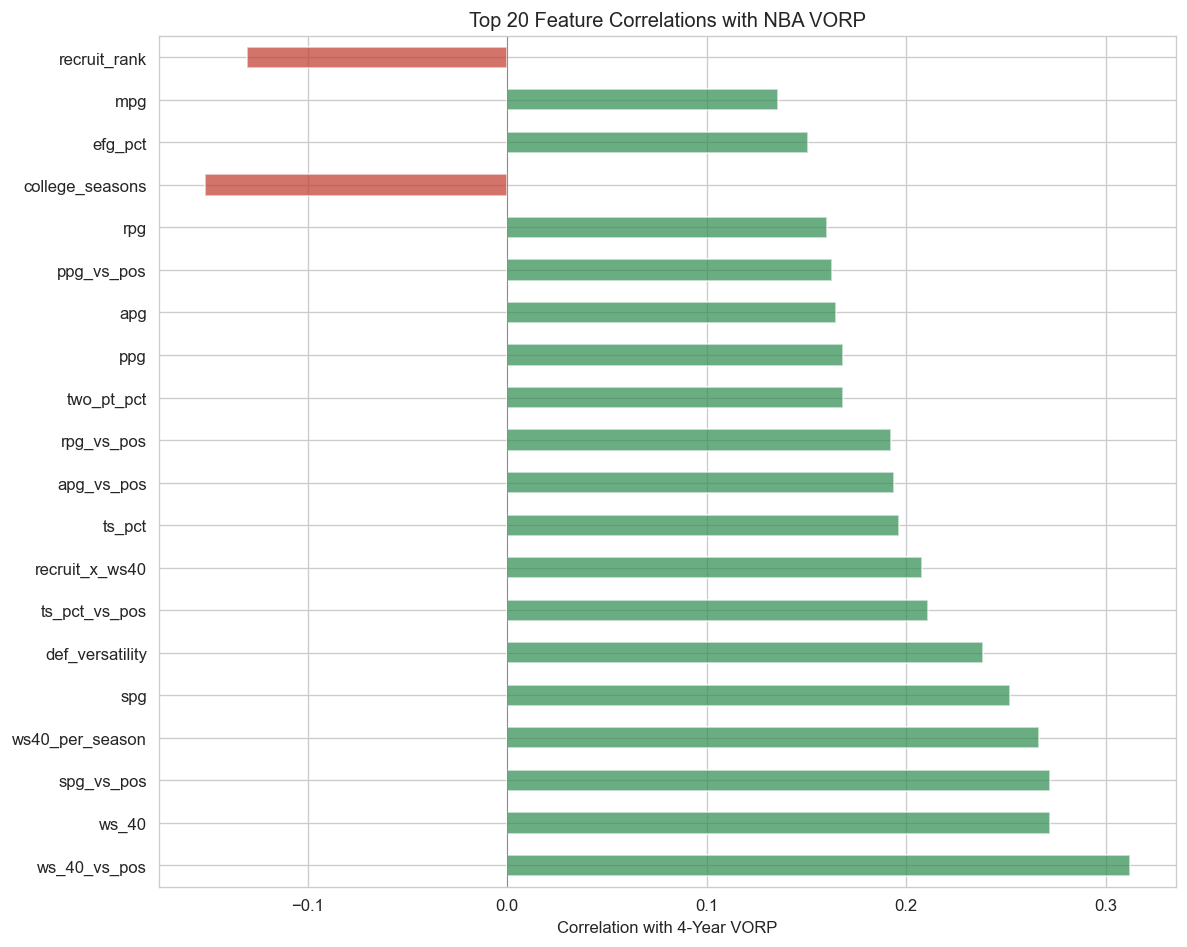

Top 15 features by |correlation| with VORP:
  ws_40_vs_pos: r = +0.312
  ws_40: r = +0.272
  spg_vs_pos: r = +0.272
  ws40_per_season: r = +0.266
  spg: r = +0.252
  def_versatility: r = +0.238
  ts_pct_vs_pos: r = +0.211
  recruit_x_ws40: r = +0.208
  ts_pct: r = +0.196
  apg_vs_pos: r = +0.194
  rpg_vs_pos: r = +0.192
  two_pt_pct: r = +0.168
  ppg: r = +0.168
  apg: r = +0.165
  ppg_vs_pos: r = +0.163


In [108]:
# --- Feature Selection: Correlation with target ---
# Define feature columns (exclude identity, leakage, and target columns)
IDENTITY_COLS = ['player_name', 'college', 'draft_year', 'pick_number']
TARGET_COLS = ['nba_seasons', 'nba_4yr_total_mp', 'nba_4yr_bpm', 'nba_4yr_vorp', 'nba_4yr_ws', 
               'career_ws48', 'meaningful_career', 'bpm_tier', 'minutes_tier', 'PosVORP']

FEATURE_COLS = [c for c in df_clean.columns if c not in IDENTITY_COLS + TARGET_COLS + ['position']]

# Correlation with VORP
feat_corr = df_clean[FEATURE_COLS + ['nba_4yr_vorp']].corr()['nba_4yr_vorp'].drop('nba_4yr_vorp')
feat_corr = feat_corr.sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#2d8a4e' if v > 0 else '#c0392b' for v in feat_corr.head(20)]
feat_corr.head(20).plot.barh(ax=ax, color=colors, alpha=0.7)
ax.set_xlabel('Correlation with 4-Year VORP')
ax.set_title('Top 20 Feature Correlations with NBA VORP')
ax.axvline(0, color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '08_feature_correlations.png', bbox_inches='tight')
plt.show()

print("Top 15 features by |correlation| with VORP:")
for feat, val in feat_corr.head(15).items():
    print(f"  {feat}: r = {val:+.3f}")

## Stage 3: Modeling & Evaluation

**Train/test split:** Temporal split at 2019 — train on draft classes 2000–2018, test on 2019–2022. This prevents temporal leakage and simulates real-world usage (predicting future draft classes from historical data).

**Models:**
1. **XGBoost** — gradient boosted trees (regression + classification)
2. **Neural Network** — MLP regressor for comparison
3. **K-Means Clustering** — unsupervised player archetype discovery

**Targets:**
- Regression: `nba_4yr_vorp`
- Classification: `PosVORP` (binary: did the player achieve positive VORP?)

In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, f1_score, confusion_matrix, roc_auc_score,
                             classification_report)
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.linear_model import Ridge
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import xgboost as xgb
import shap
import joblib
import json

# --- Temporal Train/Test Split ---
SPLIT_YEAR = 2019
train_df = df_clean[df_clean['draft_year'] < SPLIT_YEAR].copy()
test_df = df_clean[df_clean['draft_year'] >= SPLIT_YEAR].copy()

X_train = train_df[FEATURE_COLS].values
X_test = test_df[FEATURE_COLS].values
y_train_vorp = train_df['nba_4yr_vorp'].values
y_test_vorp = test_df['nba_4yr_vorp'].values
y_train_cls = train_df['PosVORP'].values
y_test_cls = test_df['PosVORP'].values

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {len(train_df)} players (2000–{SPLIT_YEAR-1})")
print(f"Test:  {len(test_df)} players ({SPLIT_YEAR}–2022)")
print(f"Features: {len(FEATURE_COLS)}")
print(f"Train VORP — mean: {y_train_vorp.mean():.2f}, std: {y_train_vorp.std():.2f}")
print(f"Train PosVORP balance: {y_train_cls.mean():.1%} positive")

Train: 851 players (2000–2018)
Test:  191 players (2019–2022)
Features: 41
Train VORP — mean: 1.19, std: 3.18
Train PosVORP balance: 44.7% positive


### Model 1: XGBoost

In [110]:
# --- XGBoost Regression with Hyperparameter Tuning ---
xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
}

xgb_reg = xgb.XGBRegressor(random_state=42, verbosity=0)
xgb_search = RandomizedSearchCV(
    xgb_reg, xgb_params, n_iter=50, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_s, y_train_vorp)

xgb_best = xgb_search.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_s)

print("XGBoost Regression — Best params:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nCV R² (train): {xgb_search.best_score_:.4f}")
print(f"Test R²:  {r2_score(y_test_vorp, y_pred_xgb):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test_vorp, y_pred_xgb):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_vorp, y_pred_xgb)):.3f}")

XGBoost Regression — Best params:
  subsample: 0.7
  n_estimators: 200
  min_child_weight: 5
  max_depth: 4
  learning_rate: 0.01
  colsample_bytree: 0.7

CV R² (train): 0.1688
Test R²:  0.2017
Test MAE: 1.666
Test RMSE: 2.290


In [111]:
# --- XGBoost Classification (PosVORP) ---
xgb_clf = xgb.XGBClassifier(random_state=42, verbosity=0)
xgb_clf_search = RandomizedSearchCV(
    xgb_clf, xgb_params, n_iter=50, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=0
)
xgb_clf_search.fit(X_train_s, y_train_cls)

xgb_clf_best = xgb_clf_search.best_estimator_
y_pred_cls_xgb = xgb_clf_best.predict(X_test_s)
y_pred_proba_xgb = xgb_clf_best.predict_proba(X_test_s)[:, 1]

print("XGBoost Classification (PosVORP):")
print(f"  CV Accuracy (train): {xgb_clf_search.best_score_:.4f}")
print(f"  Test Accuracy: {accuracy_score(y_test_cls, y_pred_cls_xgb):.4f}")
print(f"  Test F1:       {f1_score(y_test_cls, y_pred_cls_xgb):.4f}")
print(f"  Test AUC-ROC:  {roc_auc_score(y_test_cls, y_pred_proba_xgb):.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_cls_xgb, target_names=['Negative VORP', 'Positive VORP'])}")

XGBoost Classification (PosVORP):
  CV Accuracy (train): 0.6862
  Test Accuracy: 0.5654
  Test F1:       0.4908
  Test AUC-ROC:  0.5907

               precision    recall  f1-score   support

Negative VORP       0.59      0.65      0.62       104
Positive VORP       0.53      0.46      0.49        87

     accuracy                           0.57       191
    macro avg       0.56      0.56      0.56       191
 weighted avg       0.56      0.57      0.56       191



### Model 2: Neural Network

In [112]:
# --- Neural Network Regression ---
nn_params = {
    'hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16), (128, 64, 32)],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'alpha': [0.0001, 0.001, 0.01],
}

nn_reg = MLPRegressor(max_iter=1000, random_state=42, early_stopping=True, validation_fraction=0.15)
nn_search = RandomizedSearchCV(
    nn_reg, nn_params, n_iter=20, cv=5, scoring='r2',
    random_state=42, n_jobs=-1, verbose=0
)
nn_search.fit(X_train_s, y_train_vorp)

nn_best = nn_search.best_estimator_
y_pred_nn = nn_best.predict(X_test_s)

print("Neural Network Regression — Best params:")
for k, v in nn_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nCV R² (train): {nn_search.best_score_:.4f}")
print(f"Test R²:  {r2_score(y_test_vorp, y_pred_nn):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test_vorp, y_pred_nn):.3f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_vorp, y_pred_nn)):.3f}")

# --- Neural Network Classification ---
nn_clf = MLPClassifier(max_iter=1000, random_state=42, early_stopping=True, validation_fraction=0.15)
nn_clf_search = RandomizedSearchCV(
    nn_clf, nn_params, n_iter=20, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=0
)
nn_clf_search.fit(X_train_s, y_train_cls)

nn_clf_best = nn_clf_search.best_estimator_
y_pred_cls_nn = nn_clf_best.predict(X_test_s)
y_pred_proba_nn = nn_clf_best.predict_proba(X_test_s)[:, 1]

print(f"\nNeural Network Classification (PosVORP):")
print(f"  Test Accuracy: {accuracy_score(y_test_cls, y_pred_cls_nn):.4f}")
print(f"  Test F1:       {f1_score(y_test_cls, y_pred_cls_nn):.4f}")
print(f"  Test AUC-ROC:  {roc_auc_score(y_test_cls, y_pred_proba_nn):.4f}")

Neural Network Regression — Best params:
  learning_rate_init: 0.001
  hidden_layer_sizes: (128, 64)
  alpha: 0.001

CV R² (train): 0.1779
Test R²:  0.1518
Test MAE: 1.652
Test RMSE: 2.361

Neural Network Classification (PosVORP):
  Test Accuracy: 0.5550
  Test F1:       0.4785
  Test AUC-ROC:  0.5790


### Model Comparison & Evaluation Figures

In [113]:
# --- Model Comparison Table ---
# Also train a Ridge baseline for reference
ridge = Ridge(alpha=10)
ridge.fit(X_train_s, y_train_vorp)
y_pred_ridge = ridge.predict(X_test_s)

results = pd.DataFrame({
    'Model': ['Ridge (baseline)', 'XGBoost', 'Neural Network'],
    'R²': [r2_score(y_test_vorp, y_pred_ridge), r2_score(y_test_vorp, y_pred_xgb), r2_score(y_test_vorp, y_pred_nn)],
    'MAE': [mean_absolute_error(y_test_vorp, y_pred_ridge), mean_absolute_error(y_test_vorp, y_pred_xgb), mean_absolute_error(y_test_vorp, y_pred_nn)],
    'RMSE': [np.sqrt(mean_squared_error(y_test_vorp, y_pred_ridge)), np.sqrt(mean_squared_error(y_test_vorp, y_pred_xgb)), np.sqrt(mean_squared_error(y_test_vorp, y_pred_nn))],
})

cls_results = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network'],
    'Accuracy': [accuracy_score(y_test_cls, y_pred_cls_xgb), accuracy_score(y_test_cls, y_pred_cls_nn)],
    'F1': [f1_score(y_test_cls, y_pred_cls_xgb), f1_score(y_test_cls, y_pred_cls_nn)],
    'AUC-ROC': [roc_auc_score(y_test_cls, y_pred_proba_xgb), roc_auc_score(y_test_cls, y_pred_proba_nn)],
})

print("=== Regression Results (VORP Prediction) ===")
print(results.to_string(index=False))
print(f"\n=== Classification Results (Positive VORP) ===")
print(cls_results.to_string(index=False))

=== Regression Results (VORP Prediction) ===
           Model       R²      MAE     RMSE
Ridge (baseline) 0.162201 1.777340 2.346102
         XGBoost 0.201718 1.665834 2.290105
  Neural Network 0.151831 1.651838 2.360577

=== Classification Results (Positive VORP) ===
         Model  Accuracy       F1  AUC-ROC
       XGBoost  0.565445 0.490798 0.590738
Neural Network  0.554974 0.478528 0.579023


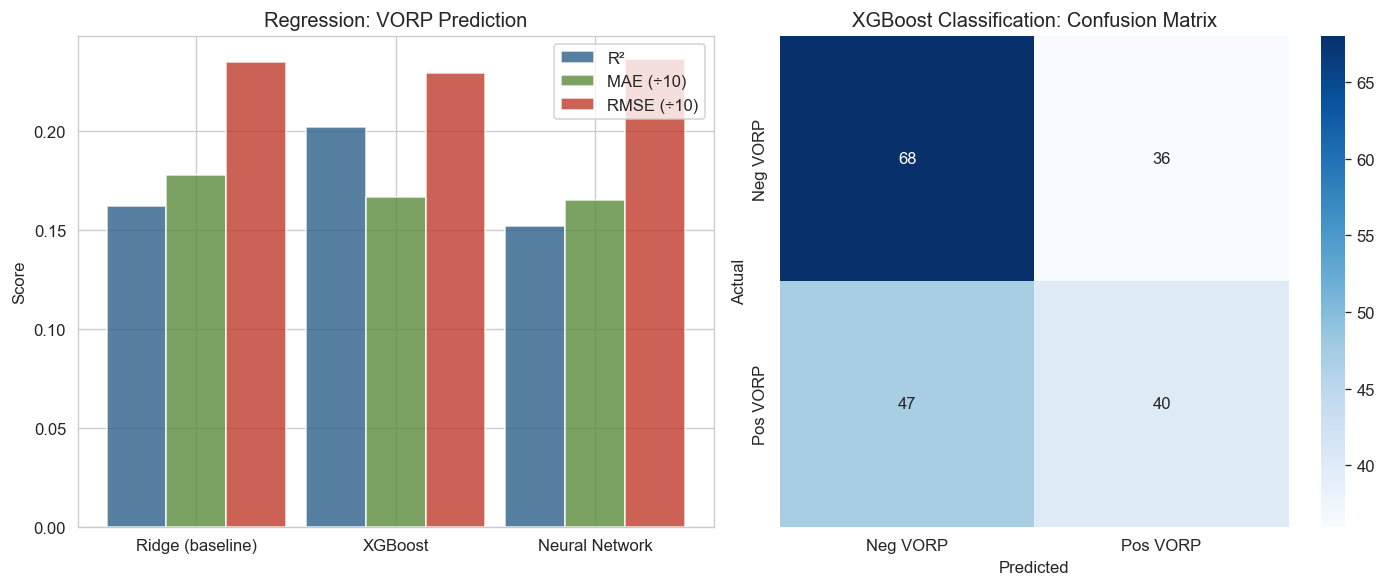

In [114]:
# --- Figure: Model Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Regression comparison
x = np.arange(len(results))
width = 0.3
axes[0].bar(x - width, results['R²'], width, label='R²', color='#2c5f8a', alpha=0.8)
axes[0].bar(x, results['MAE'] / 10, width, label='MAE (÷10)', color='#5a8a3c', alpha=0.8)
axes[0].bar(x + width, results['RMSE'] / 10, width, label='RMSE (÷10)', color='#c0392b', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'])
axes[0].legend()
axes[0].set_title('Regression: VORP Prediction')
axes[0].set_ylabel('Score')

# Confusion matrix for best classifier
cm = confusion_matrix(y_test_cls, y_pred_cls_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Neg VORP', 'Pos VORP'], yticklabels=['Neg VORP', 'Pos VORP'])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('XGBoost Classification: Confusion Matrix')

plt.tight_layout()
plt.savefig(FIGURES_DIR + '09_model_comparison.png', bbox_inches='tight')
plt.show()

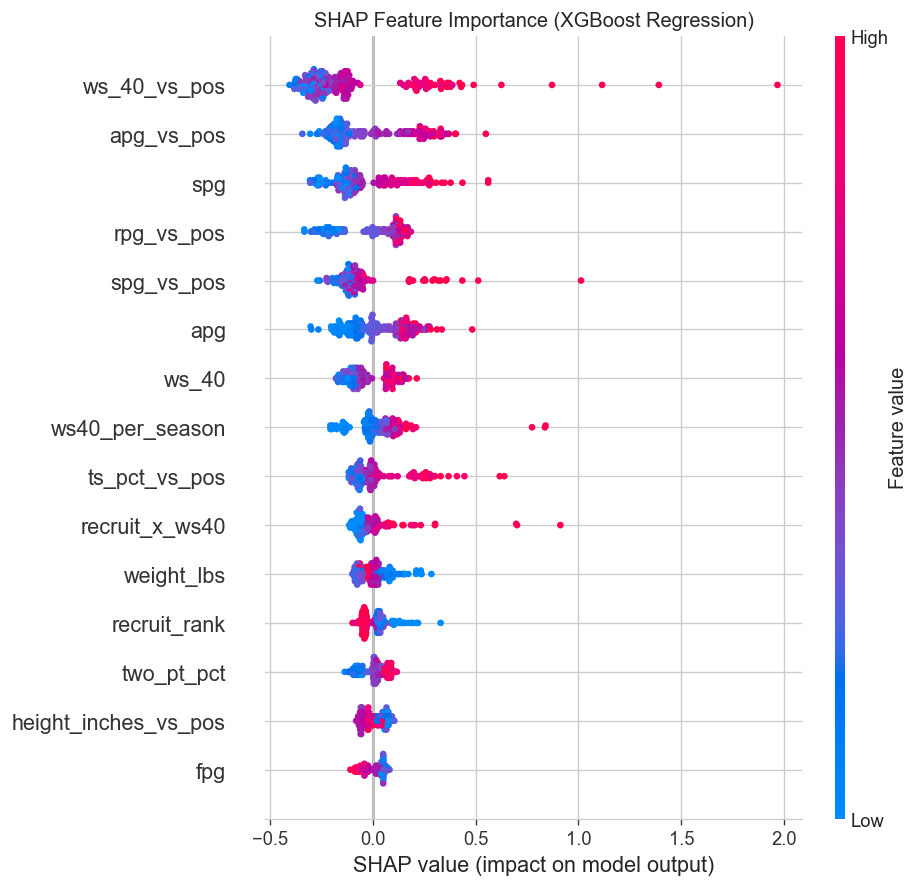

Top 10 features by mean |SHAP|:
  ws_40_vs_pos: 0.2680
  apg_vs_pos: 0.1797
  spg: 0.1486
  rpg_vs_pos: 0.1393
  spg_vs_pos: 0.1272
  apg: 0.1199
  ws_40: 0.0949
  ws40_per_season: 0.0868
  ts_pct_vs_pos: 0.0867
  recruit_x_ws40: 0.0670


In [115]:
# --- SHAP Feature Importance ---
explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test_s)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_s, feature_names=FEATURE_COLS, show=False, max_display=15)
plt.title('SHAP Feature Importance (XGBoost Regression)')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '10_shap_importance.png', bbox_inches='tight')
plt.show()

# Mean absolute SHAP for export
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_shap, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 features by mean |SHAP|:")
for feat, val in shap_importance.head(10).items():
    print(f"  {feat}: {val:.4f}")

### Model 3: K-Means Clustering (Player Archetypes)

Rather than one global K-means — which mostly just rediscovers the interior/perimeter
split — we cluster **within each position group** (Guard, Forward, Center). This yields
homogeneous archetypes: a "scoring guard" and a "scoring center" no longer collapse
into the same cluster. `k` is chosen by sample size: 3 guards, 3 forwards, 2 centers —
8 archetypes total. Global PCA is kept for a single shared visualization.


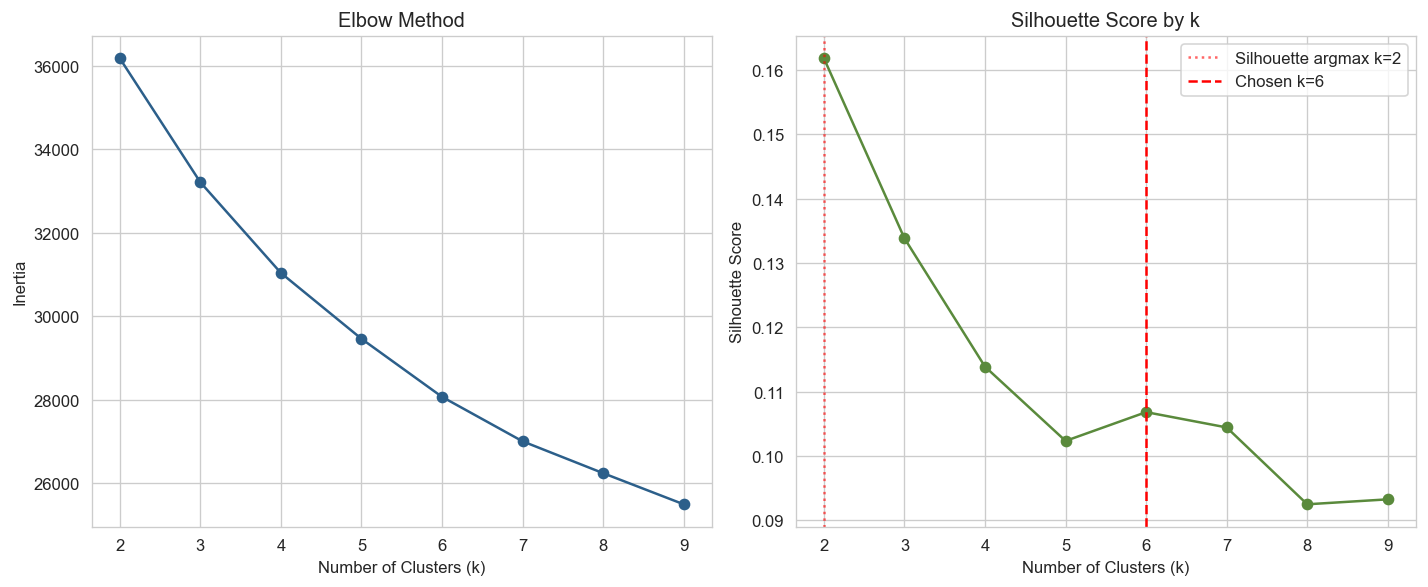

Silhouette argmax: k=2 (score=0.1618)
Chosen k = 6 (silhouette at k=6: 0.1068)


In [116]:
# --- K-Means: per-position silhouette analysis ---
# A single global K-means mostly separates interior vs. perimeter (the
# silhouette argmax was k=2). We instead cluster WITHIN each position
# group so archetypes are homogeneous by role — a "scoring guard" and a
# "scoring center" no longer collapse into the same cluster.

X_all_s = scaler.transform(df_clean[FEATURE_COLS].values)

POSITION_ORDER = ['Guard', 'Forward', 'Center']
K_BY_POSITION = {'Guard': 3, 'Forward': 3, 'Center': 2}  # tuned by counts (480/442/120)

K_range = range(2, 6)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
silhouettes_by_pos = {}
for ax, pos in zip(axes, POSITION_ORDER):
    mask = (df_clean['position'].values == pos)
    Xp = X_all_s[mask]
    sils, inertias = [], []
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xp)
        sils.append(silhouette_score(Xp, km.labels_))
        inertias.append(km.inertia_)
    silhouettes_by_pos[pos] = sils
    ax.plot(list(K_range), sils, 'o-', color='#2c5f8a', label='silhouette')
    ax.axvline(K_BY_POSITION[pos], color='#a63818', linestyle='--', alpha=0.7,
               label=f'Chosen k={K_BY_POSITION[pos]}')
    ax.set_title(f'{pos}s (n={mask.sum()})')
    ax.set_xlabel('k')
    ax.set_ylabel('silhouette')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '11_kmeans_selection.png', bbox_inches='tight')
plt.show()

for pos in POSITION_ORDER:
    sils = silhouettes_by_pos[pos]
    argmax_k = list(K_range)[np.argmax(sils)]
    print(f"  {pos:8s}: silhouette argmax={argmax_k} ({max(sils):.3f}) | chosen k={K_BY_POSITION[pos]}")


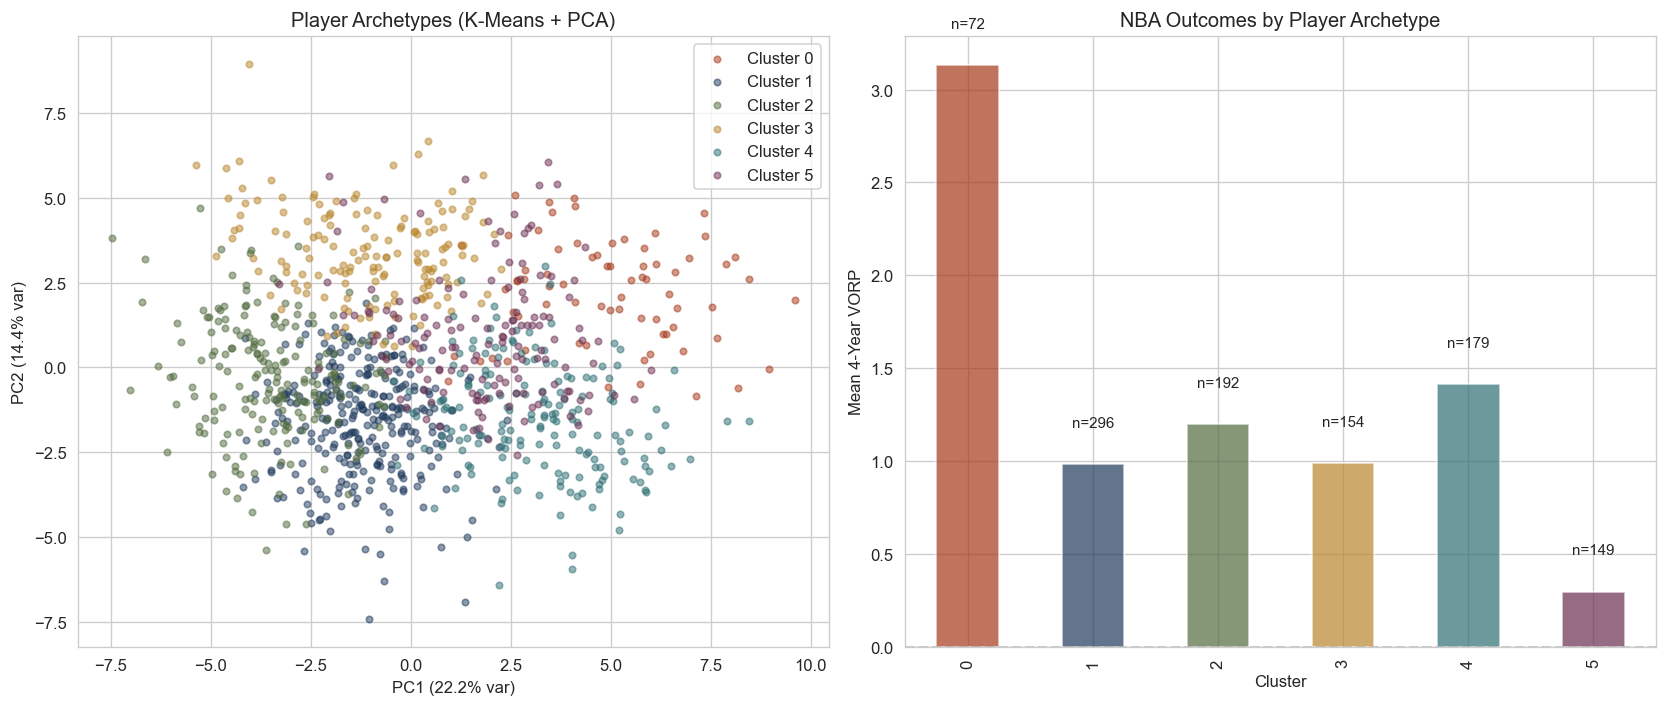

Cluster profiles (mean values):
           ppg   apg   rpg   spg   bpg  ts_pct  ws_40  recruit_rank  college_seasons
cluster                                                                             
0        14.07  1.41  7.86  0.92  1.91    0.62   0.24         19.35             1.15
1        13.76  2.18  4.55  1.03  0.42    0.57   0.17         79.41             3.32
2        13.57  4.07  4.37  1.55  0.36    0.54   0.15         72.58             2.88
3        13.82  2.27  5.30  1.08  0.64    0.54   0.15         19.80             1.17
4        13.63  1.38  7.81  0.93  1.57    0.59   0.22         74.23             3.18
5         8.32  0.93  5.25  0.60  1.15    0.56   0.17         76.08             2.95


In [117]:
# --- Fit KMeans per position, assign global cluster IDs, run global PCA ---
km_models = {}
global_cluster = np.full(len(df_clean), -1, dtype=int)
offset = 0
for pos in POSITION_ORDER:
    k = K_BY_POSITION[pos]
    mask = (df_clean['position'].values == pos)
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_all_s[mask])
    global_cluster[mask] = km.labels_ + offset
    km_models[pos] = {'model': km, 'offset': offset, 'k': k}
    offset += k

best_k = sum(K_BY_POSITION.values())  # total archetypes for downstream code
df_clean['cluster'] = global_cluster

# Global PCA for the scatter — still one projection across all positions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_s)
df_clean['pca_1'] = X_pca[:, 0]
df_clean['pca_2'] = X_pca[:, 1]

# --- Visualization ---
cluster_colors = ['#a63818', '#1f3a5c', '#516b3e', '#b9862c', '#2d6e73', '#6a2e52', '#4a4a5a', '#8b2014']
position_markers = {'Guard': 'o', 'Forward': 's', 'Center': '^'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Cluster scatter — color by cluster, shape by position
for c in range(best_k):
    mask = df_clean['cluster'] == c
    if mask.sum() == 0:
        continue
    pos_of_cluster = df_clean.loc[mask, 'position'].iloc[0]
    axes[0].scatter(df_clean.loc[mask, 'pca_1'], df_clean.loc[mask, 'pca_2'],
                    s=18, alpha=0.55,
                    color=cluster_colors[c % len(cluster_colors)],
                    marker=position_markers[pos_of_cluster],
                    label=f'Cluster {c} ({pos_of_cluster[0]})')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
axes[0].set_title('Player Archetypes (per-position K-Means + global PCA)')
axes[0].legend(fontsize=7, ncol=2, loc='upper right')

# Mean VORP per cluster
cluster_vorp = df_clean.groupby('cluster')['nba_4yr_vorp'].agg(['mean', 'count'])
cluster_vorp.plot.bar(y='mean', ax=axes[1], color=cluster_colors[:best_k], alpha=0.75, legend=False)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean 4-Year VORP')
axes[1].set_title('NBA Outcomes by Archetype')
for i, row in cluster_vorp.iterrows():
    axes[1].text(i, row['mean'] + 0.1, f"n={row['count']:.0f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR + '12_kmeans_clusters.png', bbox_inches='tight')
plt.show()

# Cluster profiles
print("Cluster profiles (mean values):")
profile_cols = ['ppg', 'apg', 'rpg', 'spg', 'bpg', 'ts_pct', 'ws_40', 'recruit_rank', 'college_seasons']
prof = df_clean.groupby(['position', 'cluster'])[profile_cols].mean().round(2)
print(prof.to_string())


## Stage 4: Export for Deployment

Export all model results to JSON files that the static frontend can consume. The frontend runs entirely client-side on GitHub Pages — no Python server needed.

In [118]:
# --- Export 1: prospects.json (all players with predictions + SHAP + comps) ---

# Generate predictions for ALL players
X_all_features = df_clean[FEATURE_COLS].values
X_all_scaled = scaler.transform(X_all_features)

all_vorp_pred = xgb_best.predict(X_all_scaled)
all_cls_proba = xgb_clf_best.predict_proba(X_all_scaled)[:, 1]

# SHAP values for all players
all_shap = explainer.shap_values(X_all_scaled)

# Build prospect records
prospects = []
for i, (_, row) in enumerate(df_clean.iterrows()):
    # Top SHAP features for this player
    player_shap = all_shap[i]
    shap_pairs = sorted(
        [(FEATURE_COLS[j], float(player_shap[j])) for j in range(len(FEATURE_COLS))],
        key=lambda x: abs(x[1]), reverse=True
    )[:5]
    
    # Find 5 nearest neighbors (comps) by Euclidean distance in feature space.
    # Restrict to same-position players — a guard's comps should be other guards.
    dists = np.sqrt(((X_all_scaled - X_all_scaled[i]) ** 2).sum(axis=1))
    dists[i] = np.inf  # exclude self
    same_pos = df_clean['position'].values == row['position']
    dists = np.where(same_pos, dists, np.inf)
    comp_idxs = np.argsort(dists)[:5]
    comps = []
    for ci in comp_idxs:
        comp_row = df_clean.iloc[ci]
        comps.append({
            'player_name': comp_row['player_name'],
            'draft_year': int(comp_row['draft_year']),
            'college': comp_row['college'],
            'position': comp_row['position'],
            'actual_vorp': round(float(comp_row['nba_4yr_vorp']), 1),
        })
    
    prospects.append({
        'player_name': row['player_name'],
        'draft_year': int(row['draft_year']),
        'college': row['college'],
        'position': row['position'],
        'ppg': round(float(row['ppg']), 1),
        'apg': round(float(row['apg']), 1),
        'rpg': round(float(row['rpg']), 1),
        'spg': round(float(row['spg']), 1),
        'bpg': round(float(row['bpg']), 1),
        'ts_pct': round(float(row['ts_pct']), 3),
        'ws_40': round(float(row['ws_40']), 3),
        'recruit_rank': int(row['recruit_rank']),
        'college_seasons': int(row['college_seasons']),
        'actual_vorp': round(float(row['nba_4yr_vorp']), 2),
        'predicted_vorp': round(float(all_vorp_pred[i]), 2),
        'posvorp_prob': round(float(all_cls_proba[i]), 3),
        'cluster': int(df_clean.iloc[i]['cluster']),
        'pca_1': round(float(df_clean.iloc[i]['pca_1']), 3),
        'pca_2': round(float(df_clean.iloc[i]['pca_2']), 3),
        'shap_features': [{'feature': f, 'shap': round(s, 3)} for f, s in shap_pairs],
        'comps': comps,
        'is_test': bool(row['draft_year'] >= SPLIT_YEAR),
    })

with open(SITE_DATA_DIR + 'prospects.json', 'w') as f:
    json.dump(prospects, f)
print(f"Exported {len(prospects)} prospects to prospects.json")

Exported 1042 prospects to prospects.json


In [119]:
# --- Export 2: model_meta.json (performance metrics, feature importances, Ridge coefficients) ---

# Ridge coefficients for client-side prediction
ridge_full = Ridge(alpha=10)
X_full_s = scaler.fit_transform(df_clean[FEATURE_COLS].values)
ridge_full.fit(X_full_s, df_clean['nba_4yr_vorp'].values)

model_meta = {
    'n_training': int(len(train_df)),
    'n_test': int(len(test_df)),
    'n_features': len(FEATURE_COLS),
    'feature_names': FEATURE_COLS,
    'split_year': SPLIT_YEAR,
    'regression_results': {
        model: {
            'r2': round(float(results.loc[results['Model'] == model, 'R²'].values[0]), 4),
            'mae': round(float(results.loc[results['Model'] == model, 'MAE'].values[0]), 3),
            'rmse': round(float(results.loc[results['Model'] == model, 'RMSE'].values[0]), 3),
        } for model in results['Model']
    },
    'classification_results': {
        model: {
            'accuracy': round(float(cls_results.loc[cls_results['Model'] == model, 'Accuracy'].values[0]), 4),
            'f1': round(float(cls_results.loc[cls_results['Model'] == model, 'F1'].values[0]), 4),
            'auc_roc': round(float(cls_results.loc[cls_results['Model'] == model, 'AUC-ROC'].values[0]), 4),
        } for model in cls_results['Model']
    },
    'feature_importances': {feat: round(float(val), 4) for feat, val in shap_importance.head(15).items()},
    # Ridge coefficients for client-side approximate prediction
    'ridge_coefficients': {feat: round(float(coef), 4) for feat, coef in zip(FEATURE_COLS, ridge_full.coef_)},
    'ridge_intercept': round(float(ridge_full.intercept_), 4),
    'scaler_mean': {feat: round(float(m), 6) for feat, m in zip(FEATURE_COLS, scaler.mean_)},
    'scaler_scale': {feat: round(float(s), 6) for feat, s in zip(FEATURE_COLS, scaler.scale_)},
}

with open(SITE_DATA_DIR + 'model_meta.json', 'w') as f:
    json.dump(model_meta, f, indent=2)
print("Exported model_meta.json")

Exported model_meta.json


In [120]:
# --- Export 3: position_stats.json (for client-side z-score computation) ---
with open(SITE_DATA_DIR + 'position_stats.json', 'w') as f:
    json.dump(pos_stats, f, indent=2)
print("Exported position_stats.json")

# --- Export 4: clusters.json (per-position archetypes + PCA variance) ---
clusters_data = {
    'n_clusters': best_k,
    'clustered_by_position': True,
    'k_per_position': K_BY_POSITION,
    'pca_variance_explained': [round(float(v), 4) for v in pca.explained_variance_ratio_[:2]],
    'cluster_profiles': {},
}
for pos in POSITION_ORDER:
    off = km_models[pos]['offset']
    for local in range(km_models[pos]['k']):
        gid = off + local
        mask = df_clean['cluster'] == gid
        if mask.sum() == 0:
            continue
        profile = df_clean.loc[mask, profile_cols].mean()
        clusters_data['cluster_profiles'][str(gid)] = {
            **{col: round(float(profile[col]), 2) for col in profile_cols},
            'position': pos,
            'local_id': local,
            'count': int(mask.sum()),
            'mean_vorp': round(float(df_clean.loc[mask, 'nba_4yr_vorp'].mean()), 2),
        }

with open(SITE_DATA_DIR + 'clusters.json', 'w') as f:
    json.dump(clusters_data, f, indent=2)
print(f"Exported clusters.json ({best_k} archetypes across {len(POSITION_ORDER)} positions)")

# --- Save model artifacts ---
joblib.dump(xgb_best, MODELS_DIR + 'xgboost_reg.pkl')
joblib.dump(xgb_clf_best, MODELS_DIR + 'xgboost_clf.pkl')
joblib.dump(nn_best, MODELS_DIR + 'nn_reg.pkl')
joblib.dump(scaler, MODELS_DIR + 'scaler.pkl')
joblib.dump(km_models, MODELS_DIR + 'kmeans.pkl')  # dict-form: {position: {model, offset, k}}
joblib.dump(ridge_full, MODELS_DIR + 'ridge.pkl')
print("Saved model artifacts to models/")


Exported position_stats.json
Exported clusters.json
Saved model artifacts to models/


### Big Board — project the incoming 2026 class


In [ ]:
# --- Export 5: bigboard.json (incoming 2026 class) ---
# Runs the trained XGBoost + kmeans + PCA + SHAP pipeline on `2026class.csv`
# and writes a ranked board to site/data/bigboard.json.

from pathlib import Path
bb_csv = Path('../2026class.csv')

if bb_csv.exists():
    bb = pd.read_csv(bb_csv)
    bb['draft_year'] = 2026
    bb['recruit_rank'] = pd.to_numeric(bb['recruit_rank'], errors='coerce').fillna(101).astype(int)

    # Guard against corrupted ws_40 (training-set max ~0.41; anything wildly
    # above that is a scraping error). Recompute from ws + mpg + seasons.
    WS40_MAX = float(df_clean['ws_40'].max())
    bad = bb['ws_40'] > WS40_MAX * 1.2
    if bad.any():
        est = bb['ws'] / (bb['mpg'] * 30 * bb['college_seasons']).clip(lower=1) * 40
        for idx in bb[bad].index:
            print(f"  capping ws_40 for {bb.loc[idx, 'player_name']}: {bb.loc[idx, 'ws_40']:.3f} -> {est.loc[idx]:.3f}")
        bb.loc[bad, 'ws_40'] = est[bad]

    # Derive recruit/seasons indicators if absent
    bb['is_top_100_recruit'] = bb.get('is_top_100_recruit', (bb['recruit_rank'] <= 100).astype(int))
    bb['is_top_10_recruit']  = bb.get('is_top_10_recruit',  (bb['recruit_rank'] <= 10).astype(int))
    bb['one_and_done']       = bb.get('one_and_done',       (bb['college_seasons'] == 1).astype(int))

    # Feature engineering — mirror cell 17 exactly
    # 1. position-relative z-scores (reuse pos_stats computed earlier)
    for stat in ['ts_pct', 'spg', 'rpg', 'apg', 'ppg', 'bpg', 'ws_40']:
        bb[f'{stat}_vs_pos'] = bb.apply(
            lambda r: (r[stat] - pos_stats[stat][r['position']]['mean'])
                      / pos_stats[stat][r['position']]['std']
            if pos_stats[stat][r['position']]['std'] > 0 else 0, axis=1
        )
    # 2-4. efficiency per season, def versatility, recruit x efficiency
    bb['ws40_per_season'] = bb['ws_40'] / bb['college_seasons'].clip(lower=1)
    bb['def_versatility'] = bb['spg'] * bb['bpg']
    bb['recruit_x_ws40']  = (101 - bb['recruit_rank']) * bb['ws_40']
    # 5. volume-weighted 3P% — same shrinkage constants as training
    bb['three_pt_pct_vw'] = (
        (bb['three_pt_pct'] * bb['three_pt_attempt_rate'] + _3p_league_mean * _3p_k)
        / (bb['three_pt_attempt_rate'] + _3p_k)
    )
    # 6. build score (recompute height/weight position norms from df_clean)
    for stat in ['height_inches', 'weight_lbs']:
        means = df_clean.groupby('position')[stat].mean()
        stds  = df_clean.groupby('position')[stat].std()
        bb[f'{stat}_vs_pos'] = bb.apply(
            lambda r: (r[stat] - means[r['position']]) / stds[r['position']], axis=1
        )
    bb['build_score'] = bb['height_inches_vs_pos'] + bb['weight_lbs_vs_pos']

    # Run models
    X_bb   = bb[FEATURE_COLS].values
    X_bb_s = scaler.transform(X_bb)
    bb_vorp    = xgb_best.predict(X_bb_s)
    bb_prob    = xgb_clf_best.predict_proba(X_bb_s)[:, 1]
    # Per-position cluster assignment using the km_models dict
    bb_cluster = np.full(len(bb), -1, dtype=int)
    for _pos, _entry in km_models.items():
        _mask = (bb['position'].values == _pos)
        if _mask.any():
            _local = _entry['model'].predict(X_bb_s[_mask])
            bb_cluster[_mask] = _local + _entry['offset']
    bb_pca     = pca.transform(X_bb_s)
    bb_shap    = explainer.shap_values(X_bb_s)

    # Historical comps: nearest 5 drafted players in scaled feature space
    bigboard = []
    for i, (_, row) in enumerate(bb.iterrows()):
        shap_pairs = sorted(
            [(FEATURE_COLS[j], float(bb_shap[i][j])) for j in range(len(FEATURE_COLS))],
            key=lambda x: abs(x[1]), reverse=True
        )[:5]
        dists = np.sqrt(((X_all_scaled - X_bb_s[i]) ** 2).sum(axis=1))
        same_pos = df_clean['position'].values == row['position']
        dists = np.where(same_pos, dists, np.inf)
        comp_idxs = np.argsort(dists)[:5]
        comps = [{
            'player_name': df_clean.iloc[ci]['player_name'],
            'draft_year':  int(df_clean.iloc[ci]['draft_year']),
            'college':     df_clean.iloc[ci]['college'],
            'position':    df_clean.iloc[ci]['position'],
            'actual_vorp': round(float(df_clean.iloc[ci]['nba_4yr_vorp']), 1),
        } for ci in comp_idxs]

        bigboard.append({
            'player_name':           row['player_name'],
            'college':               row['college'],
            'position':              row['position'],
            'height_inches':         int(row['height_inches']),
            'weight_lbs':            int(row['weight_lbs']),
            'ppg':                   round(float(row['ppg']), 1),
            'apg':                   round(float(row['apg']), 1),
            'rpg':                   round(float(row['rpg']), 1),
            'spg':                   round(float(row['spg']), 2),
            'bpg':                   round(float(row['bpg']), 2),
            'ts_pct':                round(float(row['ts_pct']), 3),
            'ws_40':                 round(float(row['ws_40']), 3),
            'three_pt_pct':          round(float(row['three_pt_pct']), 3),
            'three_pt_attempt_rate': round(float(row['three_pt_attempt_rate']), 3),
            'recruit_rank':          int(row['recruit_rank']),
            'college_seasons':       int(row['college_seasons']),
            'predicted_vorp':        round(float(bb_vorp[i]), 2),
            'posvorp_prob':          round(float(bb_prob[i]), 3),
            'cluster':               int(bb_cluster[i]),
            'pca_1':                 round(float(bb_pca[i, 0]), 3),
            'pca_2':                 round(float(bb_pca[i, 1]), 3),
            'shap_features':         [{'feature': f, 'shap': round(s, 3)} for f, s in shap_pairs],
            'comps':                 comps,
        })

    bigboard.sort(key=lambda r: -r['predicted_vorp'])
    for rank, p in enumerate(bigboard, start=1):
        p['rank'] = rank

    with open(SITE_DATA_DIR + 'bigboard.json', 'w') as f:
        json.dump(bigboard, f)

    print(f"Exported {len(bigboard)} 2026 prospects to bigboard.json")
    print("Top 10 by projected VORP:")
    for p in bigboard[:10]:
        print(f"  {p['rank']:>2}. {p['player_name']:25s} ({p['college']:20s}) -> {p['predicted_vorp']:+.2f}  P(VORP+)={p['posvorp_prob']:.2f}")
else:
    print("2026class.csv not found; skipping bigboard export")
